# WWW 마케팅 분석 포트폴리오 완성형 노트북

이 노트북은 기존 `www_final.ipynb`, `www_final2.ipynb`의 흐름을 합쳐서  
**실행 안정성 + 데이터 검증 + WWW 구조 + 핵심 가설 검증**까지 한 번에 볼 수 있도록 정리한 버전

## 이 노트북의 목표
- **Who**: 어떤 고객/세그먼트가 상대적으로 강한가?
- **When**: 오퍼를 본 뒤 얼마나 빨리 반응하는가?
- **Why**: 어떤 오퍼 속성이 전환과 연결되는가?
- **가설 검증**
  1. 고연령/고소득 그룹은 핵심 타겟 후보인가?
  2. 구매 행동은 오퍼 반응형 / 자연 구매형으로 나눠서 볼 수 있는가?
  3. 자연 구매 성향이 높은 그룹은 할인 외 전략 검토가 필요한가?

> 주의: 이 분석은 **offer instance 단위 분석**과 **customer 단위 요약 분석**을 분리해서 본다.
> 즉, "행동 유형"과 "고객 유형"을 섞지 않도록 구조를 정리

## 0. 분석 전에 먼저 확인할 점

아래 코드 셀에서는 다음을 준비

1. 라이브러리 import  
2. 한글 폰트 설정 (운영체제에 따라 자동 탐색)  
3. CSV 파일 경로 확인  
4. 출력 옵션 설정  

기존 노트북의 문제였던 **Windows 전용 폰트 하드코딩**은 제거

In [133]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 출력 옵션
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 그래프 기본 스타일
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.unicode_minus'] = False

# 운영체제에 따라 한글 폰트를 자동으로 찾도록 설정
candidate_fonts = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']
available_fonts = {f.name for f in fm.fontManager.ttflist}

selected_font = None
for font_name in candidate_fonts:
    if font_name in available_fonts:
        selected_font = font_name
        plt.rcParams['font.family'] = font_name
        break

print('선택된 폰트:', selected_font if selected_font else '기본 폰트 사용')

선택된 폰트: AppleGothic


## 1. 데이터 불러오기
- `funnel_instance.csv`
- `final_eda.csv`

In [134]:
# 현재 노트북 기준으로 자주 사용하는 경로 후보를 순서대로 확인
candidate_dirs = [
    Path('.'),
    Path('./data'),
    Path('/mnt/data')
]

funnel_path = None
eda_path = None

for base_dir in candidate_dirs:
    f1 = base_dir / 'funnel_instance.csv'
    f2 = base_dir / 'final_eda.csv'
    if f1.exists() and f2.exists():
        funnel_path = f1
        eda_path = f2
        break

if funnel_path is None or eda_path is None:
    raise FileNotFoundError(
        "funnel_instance.csv 와 final_eda.csv 를 찾지 못했습니다. "
        "노트북과 같은 폴더 또는 ./data 폴더에 두 파일을 넣고 다시 실행해 주세요."
    )

print('funnel path :', funnel_path)
print('eda path    :', eda_path)

funnel = pd.read_csv(funnel_path)
eda = pd.read_csv(eda_path)

print('funnel shape :', funnel.shape)
print('eda shape    :', eda.shape)

funnel path : funnel_instance.csv
eda path    : final_eda.csv
funnel shape : (76277, 22)
eda shape    : (306534, 29)


In [135]:
# 컬럼 구조를 먼저 확인해서 이후 merge / 파생변수 분석이 가능한지 점검
print('[funnel columns]')
print(funnel.columns.tolist())

print('\n[eda columns]')
print(eda.columns.tolist())

[funnel columns]
['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id', 'duration', 't_expire', 't_viewed', 'last_viewed', 'view_count', 'view_ambiguous', 't_completed', 'last_completed', 'complete_count', 'comp_ambiguous', 'gap_to_view', 'gap_to_complete', 'is_viewed', 'is_completed', 'completed_without_prior_view', 'completed_with_prior_view', 'gap_view_to_complete']

[eda columns]
['customer_id', 'event', 'time', 'amount', 'actual_reward', 'offer_id', 'day', 'reward', 'difficulty', 'duration', 'offer_type', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'reward_ratio', 'offer_strength', 'gender', 'age', 'became_member_on', 'income', 'is_profile_missing', 'age_group', 'age_gender', 'income_group', 'join_year', 'join_month', 'join_cohort']


## 2. lookup 테이블 만들기 전, key 품질 점검

아래 코드 셀에서는

- `customer_id`
- `offer_id`

기준으로 고객 lookup / 오퍼 lookup 을 만들기 전에  
중복과 누락 여부를 먼저 확인

> merge 후 row 수가 예상과 다르게 늘어나거나 줄어드는 문제를 예방하는 데 중요

In [136]:
# 고객 lookup 에 사용할 컬럼
cust_cols = [
    'customer_id',
    'gender', 'age', 'income',
    'age_group', 'income_group'
]

# 오퍼 lookup 에 사용할 컬럼
offer_cols = [
    'offer_id',
    'offer_type',
    'difficulty', 'reward',
    'ch_web', 'ch_email', 'ch_mobile', 'ch_social',
    'channel_count', 'reward_ratio', 'offer_strength'
]

# 필요한 컬럼이 실제로 존재하는지 확인
missing_cust_cols = [c for c in cust_cols if c not in eda.columns]
missing_offer_cols = [c for c in offer_cols if c not in eda.columns]

if missing_cust_cols:
    raise KeyError(f'eda에 없는 고객 컬럼: {missing_cust_cols}')
if missing_offer_cols:
    raise KeyError(f'eda에 없는 오퍼 컬럼: {missing_offer_cols}')

# 고객 / 오퍼 lookup 생성
cust_df = eda[cust_cols].drop_duplicates(subset=['customer_id']).copy()
offer_df = eda[offer_cols].drop_duplicates(subset=['offer_id']).copy()

print('cust_df shape :', cust_df.shape)
print('offer_df shape:', offer_df.shape)

print('\n[cust_df customer_id 중복 개수]')
print(cust_df.duplicated('customer_id').sum())

print('\n[offer_df offer_id 중복 개수]')
print(offer_df.duplicated('offer_id').sum())

cust_df shape : (17000, 6)
offer_df shape: (11, 11)

[cust_df customer_id 중복 개수]
0

[offer_df offer_id 중복 개수]
0


## 3. merge 수행 + row 폭발 여부 점검
1. 고객 merge 후 row 수가 유지되는가?  
2. 오퍼 merge 후 row 수가 유지되는가?  
3. merge 후 누락률은 어느 정도인가?  
4. `offer_type_x`, `offer_type_y` 같은 중복 컬럼이 생기면 안전하게 정리하는가?

In [137]:
# merge 전 원본 row 수를 기억해 둠
before_rows = len(funnel)

# 1차 merge: customer 정보 연결
base_df = funnel.merge(
    cust_df,
    on='customer_id',
    how='left',
    validate='m:1'
)

after_customer_merge_rows = len(base_df)

# 2차 merge: offer 정보 연결
base_df = base_df.merge(
    offer_df,
    on='offer_id',
    how='left',
    validate='m:1',
    suffixes=('', '_offer')
)

after_offer_merge_rows = len(base_df)

print('merge 전 row 수               :', before_rows)
print('customer merge 후 row 수     :', after_customer_merge_rows)
print('offer merge 후 row 수        :', after_offer_merge_rows)

if before_rows != after_customer_merge_rows:
    print('주의: customer merge 후 row 수가 변경되었습니다.')
if before_rows != after_offer_merge_rows:
    print('주의: offer merge 후 row 수가 변경되었습니다.')

merge 전 row 수               : 76277
customer merge 후 row 수     : 76277
offer merge 후 row 수        : 76277


In [138]:
# offer_type 중복 컬럼이 생기는 경우를 안전하게 처리
# 원래 funnel에 offer_type이 있고, offer lookup에도 offer_type이 있으면 중복이 생길 수 있음
if 'offer_type_offer' in base_df.columns:
    # 두 컬럼이 모두 있으면 값이 같은지 먼저 점검
    same_ratio = (base_df['offer_type'].astype(str) == base_df['offer_type_offer'].astype(str)).mean()
    print('offer_type 일치 비율:', round(same_ratio, 4))

    # 최종적으로는 원래 offer_type 하나만 남김
    # 값이 비어 있는 경우를 대비해 combine_first 사용
    base_df['offer_type'] = base_df['offer_type'].combine_first(base_df['offer_type_offer'])
    base_df = base_df.drop(columns=['offer_type_offer'])

print(base_df.columns.tolist())

offer_type 일치 비율: 1.0
['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id', 'duration', 't_expire', 't_viewed', 'last_viewed', 'view_count', 'view_ambiguous', 't_completed', 'last_completed', 'complete_count', 'comp_ambiguous', 'gap_to_view', 'gap_to_complete', 'is_viewed', 'is_completed', 'completed_without_prior_view', 'completed_with_prior_view', 'gap_view_to_complete', 'gender', 'age', 'income', 'age_group', 'income_group', 'difficulty', 'reward', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'reward_ratio', 'offer_strength']


In [139]:
# merge 후 누락률 점검
check_cols = [
    'gender', 'age_group', 'income_group',
    'offer_type', 'difficulty', 'reward', 'reward_ratio', 'offer_strength'
]

missing_report = base_df[check_cols].isna().mean().sort_values(ascending=False)
missing_report.to_frame('missing_rate')

,missing_rate
gender,0.0
age_group,0.0
income_group,0.0
offer_type,0.0
difficulty,0.0
reward,0.0
reward_ratio,0.0
offer_strength,0.0


## 4. 분석용 데이터프레임 분리

기존 노트북에서는 하나의 `df` 안에서 여러 목적을 섞어 사용  
이번에는 목적별로 나눔

- `base_df` : 전체 offer instance 기준 분석용
- `responsive_df` : 오퍼를 보고 구매한 사례 중심 분석용
- `completed_df` : 구매 완료된 사례만 분석용
- `customer_level_df` : 고객 단위 요약 분석용

"행동 유형" | "고객 유형"

In [140]:
# 전체 분석용
base_df = base_df.copy()

# ---------------------------
# 1) bool/int 혼선 방지: is_ 계열을 int로 통일
# ---------------------------
flag_cols = ['is_viewed', 'is_completed', 'completed_without_prior_view']
for col in flag_cols:
    if col in base_df.columns:
        base_df[col] = base_df[col].astype(int)

# ---------------------------
# 2) completed_with_prior_view 복구
#    (현재 funnel_instance.csv에는 이 컬럼이 없음)
# ---------------------------
if 'completed_with_prior_view' not in base_df.columns:
    base_df['completed_with_prior_view'] = (
        (base_df['is_completed'] == 1) &
        (base_df['completed_without_prior_view'] == 0)
    ).astype(int)

# 팀원 논의안 alias
base_df['aware_completed'] = base_df['completed_with_prior_view']
base_df['non_aware_completed'] = base_df['completed_without_prior_view']

# ---------------------------
# 3) 행동 유형 분류
# ---------------------------
conditions = [
    (base_df['is_completed'] == 1) & (base_df['completed_with_prior_view'] == 1),
    (base_df['is_completed'] == 1) & (base_df['completed_without_prior_view'] == 1),
    (base_df['is_completed'] == 0)
]
choices = ['Offer_Responsive', 'Usual_Purchase', 'Not_Completed']

base_df['behavior_type'] = np.select(conditions, choices, default='Other')

# ---------------------------
# 4) 분석용 서브셋
# ---------------------------
responsive_df = base_df[
    (base_df['is_completed'] == 1) &
    (base_df['completed_with_prior_view'] == 1)
].copy()

completed_df = base_df[base_df['is_completed'] == 1].copy()

print('base_df shape      :', base_df.shape)
print('responsive_df shape:', responsive_df.shape)
print('completed_df shape :', completed_df.shape)

base_df[['is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].head()

base_df shape      : (76277, 39)
responsive_df shape: (20548, 39)
completed_df shape : (33101, 39)


,is_viewed,is_completed,completed_with_prior_view,completed_without_prior_view
0,0,1,0,1
1,1,0,0,0
2,1,0,0,0
3,1,1,0,1
4,1,1,0,1


In [141]:
customer_level_df = (
    base_df.assign(
        aware_completed_flag=base_df['completed_with_prior_view'].astype(int),
        non_aware_completed_flag=base_df['completed_without_prior_view'].astype(int),
        completed_flag=base_df['is_completed'].astype(int)
    )
    .groupby('customer_id')
    .agg(
        n_offers=('offer_id', 'count'),
        completed_cnt=('completed_flag', 'sum'),
        aware_completed_cnt=('aware_completed_flag', 'sum'),
        non_aware_completed_cnt=('non_aware_completed_flag', 'sum'),
        gender=('gender', 'first'),
        age_group=('age_group', 'first'),
        income_group=('income_group', 'first'),
        age=('age', 'first'),
        income=('income', 'first')
    )
    .reset_index()
)

customer_level_df['completion_rate_by_customer'] = customer_level_df['completed_cnt'] / customer_level_df['n_offers']
customer_level_df['aware_complete_rate_by_customer'] = customer_level_df['aware_completed_cnt'] / customer_level_df['n_offers']
customer_level_df['non_aware_complete_rate_by_customer'] = customer_level_df['non_aware_completed_cnt'] / customer_level_df['n_offers']

## 5. 핵심 세그먼트 정의

기존 분석의 핵심 가설인 **고연령 + 고소득 그룹**을 그대로 사용하되,  
이번에는 다음 두 수준에서 확인

1. **instance 기준 세그먼트** (`base_df`)  
2. **customer 기준 세그먼트** (`customer_level_df`)  

>"행동 row 기준으로 많이 보인 것인지",  
>> OR "고객 자체가 정말 강한 것인지"를 조금 더 구분해서 해석

In [142]:
# instance 기준 세그먼트
base_df['is_high_age'] = base_df['age_group'].isin(['50대', '60대 이상'])
base_df['is_high_income'] = base_df['income_group'].isin(['7.5-10만', '10만 이상'])

base_df['target_segment'] = np.where(
    base_df['is_high_age'] & base_df['is_high_income'],
    'HighAge_HighIncome',
    'Others'
)

# customer 기준 세그먼트
customer_level_df['is_high_age'] = customer_level_df['age_group'].isin(['50대', '60대 이상'])
customer_level_df['is_high_income'] = customer_level_df['income_group'].isin(['7.5-10만', '10만 이상'])

customer_level_df['target_segment'] = np.where(
    customer_level_df['is_high_age'] & customer_level_df['is_high_income'],
    'HighAge_HighIncome',
    'Others'
)

print('[instance 기준]')
display(base_df['target_segment'].value_counts(dropna=False))

print('[customer 기준]')
display(customer_level_df['target_segment'].value_counts(dropna=False))

[instance 기준]


target_segment
Others                58537
HighAge_HighIncome    17740
Name: count, dtype: int64

[customer 기준]


target_segment
Others                13028
HighAge_HighIncome     3966
Name: count, dtype: int64

In [143]:
def funnel_metrics(df, group_col='offer_type'):
    out = (
        df.groupby(group_col)
        .agg(
            received=('instance_id', 'count'),
            viewed=('is_viewed', 'sum'),
            completed=('is_completed', 'sum'),
            aware_completed=('completed_with_prior_view', 'sum'),
            non_aware_completed=('completed_without_prior_view', 'sum'),
        )
        .assign(
            view_rate=lambda d: d['viewed'] / d['received'],
            complete_rate=lambda d: d['completed'] / d['received'],
            view_cvr=lambda d: np.where(d['viewed'] > 0, d['aware_completed'] / d['viewed'], np.nan),
            eff_cvr=lambda d: np.where(d['completed'] > 0, d['aware_completed'] / d['completed'], np.nan),
            non_eff_cvr=lambda d: np.where(d['completed'] > 0, d['non_aware_completed'] / d['completed'], np.nan),
        )
        .reset_index()
    )
    return out

# 6. WHO 분석

>"누가 더 잘 반응하는가?"

- 성별 / 연령대별 완료율
- 고연령/고소득 세그먼트의 성과
- 고객 단위에서 봐도 같은 방향성이 나오는지 확인

In [144]:
who_gender = (
    funnel_metrics(base_df, 'gender')
    .sort_values('complete_rate', ascending=False)
)

who_gender

,gender,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,non_eff_cvr
0,F,27456,20295,15297,9067,4871,0.739183,0.557146,0.446760,0.592731,0.318428
2,O,916,769,493,327,107,0.839520,0.538210,0.425228,0.663286,0.217039
1,M,38129,27779,16210,10265,4688,0.728553,0.425136,0.369524,0.633251,0.289204
3,Unknown,9776,7724,1101,889,168,0.790098,0.112623,0.115096,0.807448,0.152589


In [145]:
who_age = (
    funnel_metrics(base_df, 'age_group')
    .sort_values('complete_rate', ascending=False)
)

who_age

,age_group,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,non_eff_cvr
4,50대,15894,11748,8161,4908,2532,0.739147,0.513464,0.417773,0.601397,0.310256
5,60대 이상,26331,19385,13429,8167,4178,0.736204,0.510007,0.421305,0.608161,0.311118
3,40대,10288,7993,4788,3160,1188,0.776925,0.465397,0.395346,0.659983,0.248120
2,30대,6893,4888,2960,1845,867,0.709125,0.429421,0.377455,0.623311,0.292905
0,20대,6174,4193,2347,1391,790,0.679138,0.380143,0.331743,0.592671,0.336600
1,20대 미만,921,636,315,188,111,0.690554,0.342020,0.295597,0.596825,0.352381
6,누락,9776,7724,1101,889,168,0.790098,0.112623,0.115096,0.807448,0.152589


offer_type,bogo,discount,informational
age_group,,,
20대,0.427,0.511,0.0
20대 미만,0.367,0.513,0.0
30대,0.494,0.578,0.0
40대,0.549,0.614,0.0
50대,0.622,0.664,0.0
60대 이상,0.605,0.672,0.0
누락,0.101,0.180,0.0


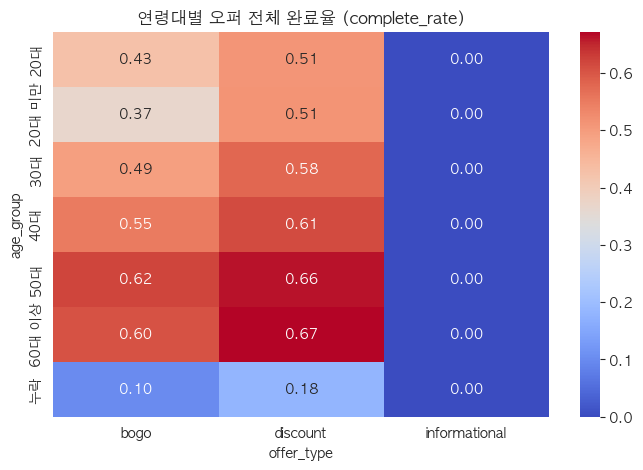

In [146]:
pivot_age_offer = base_df.pivot_table(
    index='age_group',
    columns='offer_type',
    values='is_completed',
    aggfunc='mean'
)

pivot_age_offer = pivot_age_offer.round(3)
display(pivot_age_offer)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_age_offer, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('연령대별 오퍼 전체 완료율 (complete_rate)')
plt.xlabel('offer_type')
plt.ylabel('age_group')
plt.show()

In [147]:
target_summary_instance = (
    funnel_metrics(base_df, 'target_segment')
)

target_summary_instance

,target_segment,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,non_eff_cvr
0,HighAge_HighIncome,17740,12892,10645,6117,3617,0.726719,0.600056,0.474480,0.574636,0.339784
1,Others,58537,43675,22456,14431,6217,0.746109,0.383621,0.330418,0.642634,0.276853


In [148]:
#위의 지표에 'usual_purchase_rate' 추가
target_summary_instance = (
    funnel_metrics(base_df, 'target_segment')
    .merge(
        base_df.groupby('target_segment')['completed_without_prior_view']
        .mean()
        .reset_index(name='usual_purchase_rate'),
        on='target_segment',
        how='left'
    )
)

target_summary_instance

,target_segment,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,non_eff_cvr,usual_purchase_rate
0,HighAge_HighIncome,17740,12892,10645,6117,3617,0.726719,0.600056,0.474480,0.574636,0.339784,0.203890
1,Others,58537,43675,22456,14431,6217,0.746109,0.383621,0.330418,0.642634,0.276853,0.106206


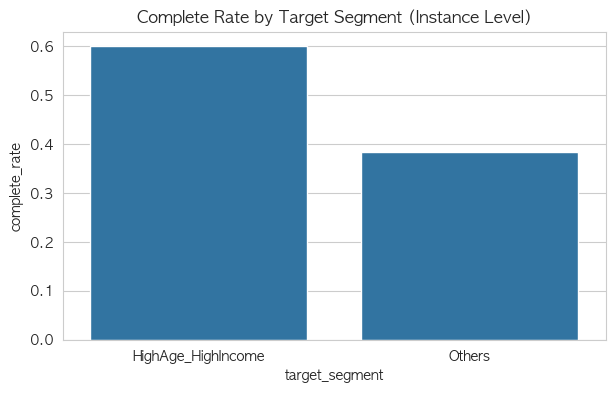

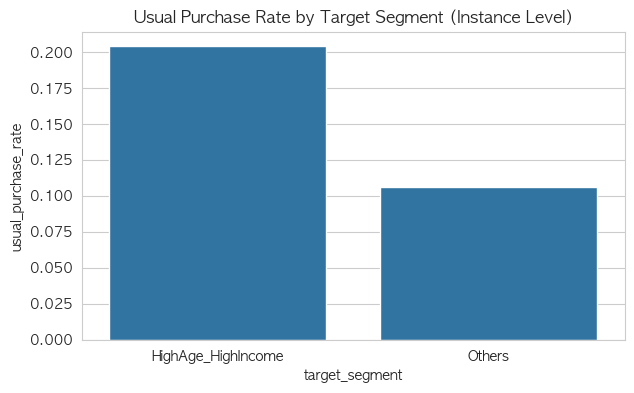

In [149]:
plt.figure(figsize=(7, 4))
sns.barplot(data=target_summary_instance, x='target_segment', y='complete_rate')
plt.title('Complete Rate by Target Segment (Instance Level)')
plt.ylabel('complete_rate')
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(data=target_summary_instance, x='target_segment', y='usual_purchase_rate')
plt.title('Usual Purchase Rate by Target Segment (Instance Level)')
plt.ylabel('usual_purchase_rate')
plt.show()

In [150]:
# 핵심 세그먼트 요약 - customer 기준
target_summary_customer = (
    customer_level_df.groupby('target_segment')
    .agg(
        customers=('customer_id', 'count'),
        avg_completion_rate=('completion_rate_by_customer', 'mean'),
        avg_responsive_share=('responsive_share', 'mean'),
        avg_usual_share=('usual_share', 'mean')
    )
    .reset_index()
)

target_summary_customer

KeyError: "Label(s) ['responsive_share', 'usual_share'] do not exist"

## WHO 통계 검정

>instance 기준으로 고연령/고소득 vs 기타 그룹의 완료율 차이를 간단한 비율검정으로 확인

#### 해석 주의  
> 이 검정은 **offer instance 기준**이며, 반복 관측 문제까지 완벽히 해결하는 검정은 아님
>> 그래도 현재 코드 수준에서는 핵심 세그먼트 차이를 빠르게 확인하는 용도로 충분히 의미가 있음

In [ ]:
grp = base_df.groupby('target_segment')['is_completed'].agg(['sum', 'count'])
grp

,sum,count
target_segment,,
HighAge_HighIncome,10645,17740
Others,22456,58537


In [ ]:
count = grp['sum'].values
nobs = grp['count'].values

stat, pval = proportions_ztest(count=count, nobs=nobs)

print('z-stat :', stat)
print('p-value:', pval)

if pval < 0.05:
    print('=> 두 그룹의 완료율 차이는 통계적으로 유의하다고 볼 수 있습니다.')
else:
    print('=> 두 그룹의 완료율 차이가 통계적으로 유의하다고 보기 어렵습니다.')

z-stat : 50.95374221241875
p-value: 0.0
=> 두 그룹의 완료율 차이는 통계적으로 유의하다고 볼 수 있습니다.


# 7. WHY 분석

> "무엇이 전환과 연결되는가?"

- 오퍼 유형별 완료율
- reward_ratio / difficulty / reward / offer_strength 와의 관계
- 행동 유형별 오퍼 mix 비교

In [ ]:
why_offer = (
    funnel_metrics(base_df, 'offer_type')
    .sort_values('complete_rate', ascending=False)
)

why_offer

,offer_type,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,non_eff_cvr
1,discount,30543,21370,17600,12326,5274,0.699669,0.576237,0.576790,0.700341,0.299659
0,bogo,30499,25250,15501,10941,4560,0.827896,0.508246,0.433307,0.705825,0.294175
2,informational,15235,9947,0,0,0,0.652904,0.000000,0.000000,NaN,NaN


In [ ]:
reward_ratio_summary = (
    base_df.groupby('reward_ratio')
    .agg(
        n=('customer_id', 'count'),
        complete_rate=('is_completed', 'mean')
    )
    .sort_values('complete_rate', ascending=False)
)

difficulty_summary = (
    base_df.groupby('difficulty')
    .agg(
        n=('customer_id', 'count'),
        complete_rate=('is_completed', 'mean')
    )
    .sort_values('complete_rate', ascending=False)
)

reward_summary = (
    base_df.groupby('reward')
    .agg(
        n=('customer_id', 'count'),
        complete_rate=('is_completed', 'mean')
    )
    .sort_values('complete_rate', ascending=False)
)

offer_strength_summary = (
    base_df.groupby('offer_strength')
    .agg(
        n=('customer_id', 'count'),
        complete_rate=('is_completed', 'mean')
    )
    .sort_values('complete_rate', ascending=False)
)

In [ ]:
# 완료 사례에서 행동 유형별 오퍼 mix 비교
offer_mix = pd.crosstab(
    completed_df['behavior_type'],
    completed_df['offer_type'],
    normalize='index'
)

offer_mix

offer_type,bogo,discount
behavior_type,,
Offer_Responsive,0.470237,0.529763
Usual_Purchase,0.463697,0.536303


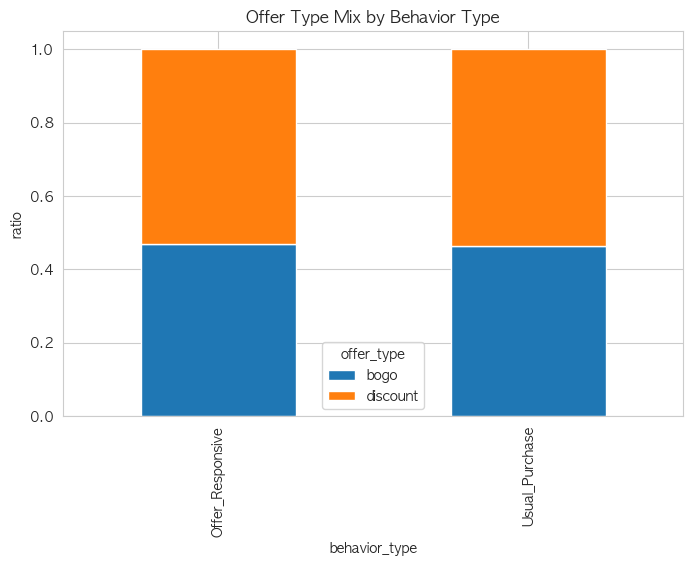

In [ ]:
offer_mix.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Offer Type Mix by Behavior Type')
plt.ylabel('ratio')
plt.show()

## 행동 유형과 세그먼트의 관계

**고연령/고소득 세그먼트에서 자연 구매/오퍼 반응형 비중이 다른가?** 

In [ ]:
type_by_target = pd.crosstab(
    base_df['target_segment'],
    base_df['behavior_type'],
    normalize='index'
)

type_by_target

behavior_type,Not_Completed,Offer_Responsive,Usual_Purchase
target_segment,,,
HighAge_HighIncome,0.399944,0.396167,0.203890
Others,0.616379,0.277414,0.106206


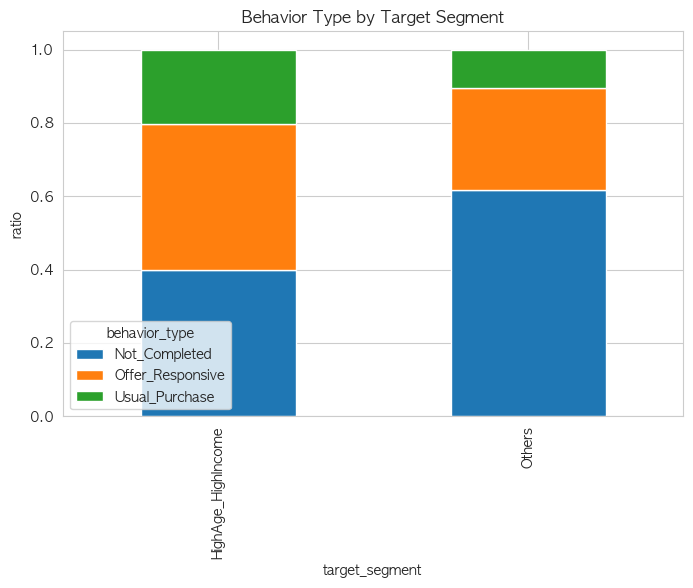

In [ ]:
type_by_target.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Behavior Type by Target Segment')
plt.ylabel('ratio')
plt.show()

In [ ]:
cont_table = pd.crosstab(base_df['target_segment'], base_df['behavior_type'])
cont_table

behavior_type,Not_Completed,Offer_Responsive,Usual_Purchase
target_segment,,,
HighAge_HighIncome,7095,7028,3617
Others,36081,16239,6217


In [ ]:
chi2, pval, dof, expected = chi2_contingency(cont_table)

print('chi2   :', chi2)
print('p-value:', pval)
print('dof    :', dof)

if pval < 0.05:
    print('=> 세그먼트와 행동 유형 분포는 독립이라고 보기 어려움')
else:
    print('=> 세그먼트와 행동 유형 분포 차이가 뚜렷하다고 보기 어려움')

chi2   : 2763.69433986294
p-value: 0.0
dof    : 2
=> 세그먼트와 행동 유형 분포는 독립이라고 보기 어려움


# 8. WHEN 분석

> **"얼마나 빨리 반응하는가"**

복잡한 시간대 분석 대신 **<오퍼를 본 뒤 완료까지 걸리는 시간 차이>**

In [ ]:
# 오퍼를 보고 구매한 사례만 대상으로 view -> complete 시간 차이를 분석
responsive_time_df = base_df[
    (base_df['behavior_type'] == 'Offer_Responsive') &
    (base_df['gap_view_to_complete'].notna())
].copy()

responsive_time_df[['offer_type', 'gap_view_to_complete']].head()

,offer_type,gap_view_to_complete
7,discount,144.0
8,discount,66.0
11,bogo,60.0
12,bogo,84.0
15,discount,42.0


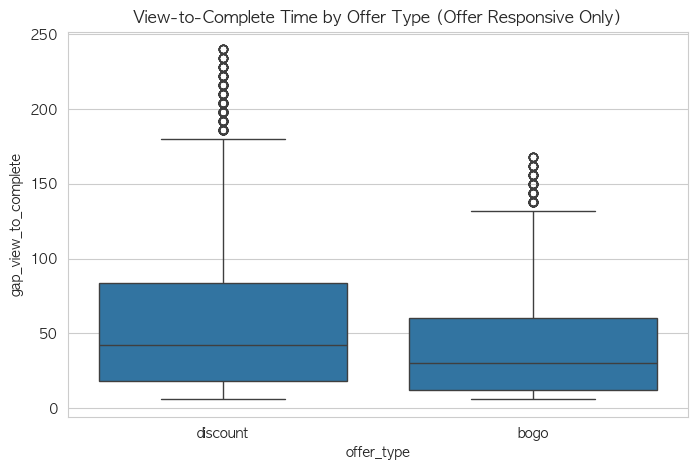

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=responsive_time_df, x='offer_type', y='gap_view_to_complete')
plt.title('View-to-Complete Time by Offer Type (Offer Responsive Only)')
plt.ylabel('gap_view_to_complete')
plt.show()

In [ ]:
# BOGO vs Discount의 행동 속도 차이 검정
x = responsive_time_df.loc[responsive_time_df['offer_type'] == 'bogo', 'gap_view_to_complete']
y = responsive_time_df.loc[responsive_time_df['offer_type'] == 'discount', 'gap_view_to_complete']

# 두 그룹의 데이터가 모두 존재할 때만 검정
if len(x) > 0 and len(y) > 0:
    stat, pval = mannwhitneyu(x, y, alternative='two-sided')
    print('Mann-Whitney U:', stat)
    print('p-value       :', pval)

    if pval < 0.05:
        print('=> 두 오퍼의 반응 속도 분포 차이는 유의하다고 볼 수 있음')
    else:
        print('=> 두 오퍼의 반응 속도 차이가 유의하다고 보기 어려움.')
else:
    print('비교할 데이터가 부족')

Mann-Whitney U: 42782219.0
p-value       : 8.752133481182945e-115
=> 두 오퍼의 반응 속도 분포 차이는 유의하다고 볼 수 있음


In [ ]:
# 반응 속도를 이해하기 쉽게 구간화
responsive_time_df['speed_group'] = pd.cut(
    responsive_time_df['gap_view_to_complete'],
    bins=[-1, 24, 72, 168, np.inf],
    labels=['Within_1d', '1to3d', '3to7d', 'Over_7d']
)

speed_summary = pd.crosstab(
    responsive_time_df['offer_type'],
    responsive_time_df['speed_group'],
    normalize='index'
)

speed_summary

speed_group,Within_1d,1to3d,3to7d,Over_7d
offer_type,,,,
bogo,0.431531,0.396048,0.172421,0.000000
discount,0.331567,0.364077,0.272564,0.031792


# 9. 고객 단위 관점 추가

> "오퍼 반응형 vs 자연 구매형"을 **진짜 고객 단위**에서 간단히 확인

In [ ]:
customer_type_summary = (
    customer_level_df.groupby('customer_type')
    .agg(
        customers=('customer_id', 'count'),
        avg_completion_rate=('completion_rate_by_customer', 'mean'),
        avg_responsive_share=('responsive_share', 'mean'),
        avg_usual_share=('usual_share', 'mean')
    )
    .sort_values('customers', ascending=False)
)

customer_type_summary

,customers,avg_completion_rate,avg_responsive_share,avg_usual_share
customer_type,,,,
Mixed,13019,0.311006,0.198708,0.112297
Offer_Responsive_Customer,3410,0.830283,0.739218,0.091065
usual_Purchase_Customer,565,0.878614,0.192684,0.685929


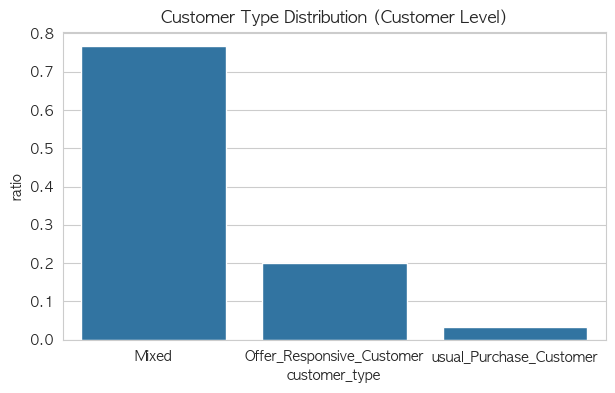

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=customer_level_df['customer_type'].value_counts(normalize=True).rename_axis('customer_type').reset_index(name='ratio'),
    x='customer_type',
    y='ratio'
)
plt.title('Customer Type Distribution (Customer Level)')
plt.ylabel('ratio')
plt.show()

In [ ]:
customer_type_by_segment = pd.crosstab(
    customer_level_df['target_segment'],
    customer_level_df['customer_type'],
    normalize='index'
)

customer_type_by_segment

customer_type,Mixed,Offer_Responsive_Customer,usual_Purchase_Customer
target_segment,,,
HighAge_HighIncome,0.665910,0.273071,0.061019
Others,0.796592,0.178615,0.024793


# 10. 최종 인사이트 테이블

- 핵심 타겟 세그먼트의 완료율
- 자연 구매 비율
- 행동 유형 분포
- 고객 단위 대표 성향 분포

In [ ]:
final_segment_table = target_summary_instance.copy()

behavior_mix_table = pd.crosstab(
    base_df['target_segment'],
    base_df['behavior_type'],
    normalize='index'
).reset_index()

customer_mix_table = pd.crosstab(
    customer_level_df['target_segment'],
    customer_level_df['customer_type'],
    normalize='index'
).reset_index()

print('[1] 세그먼트 핵심 성과')
display(final_segment_table)

print('[2] 세그먼트별 행동 유형 분포 (instance 기준)')
display(behavior_mix_table)

print('[3] 세그먼트별 고객 성향 분포 (customer 기준)')
display(customer_mix_table)

[1] 세그먼트 핵심 성과


,target_segment,n,viewed_rate,completion_rate,usual_purchase_rate
0,HighAge_HighIncome,17740,0.726719,0.600056,0.203890
1,Others,58537,0.746109,0.383621,0.106206


[2] 세그먼트별 행동 유형 분포 (instance 기준)


behavior_type,target_segment,Not_Completed,Offer_Responsive,Usual_Purchase
0,HighAge_HighIncome,0.399944,0.396167,0.203890
1,Others,0.616379,0.277414,0.106206


[3] 세그먼트별 고객 성향 분포 (customer 기준)


customer_type,target_segment,Mixed,Offer_Responsive_Customer,usual_Purchase_Customer
0,HighAge_HighIncome,0.665910,0.273071,0.061019
1,Others,0.796592,0.178615,0.024793


# 11. 해석 정리

 **자동 요약 문장**

In [ ]:
best_age_group = who_age['completion_rate'].idxmax() if len(who_age) > 0 else None
best_offer_type = why_offer['completion_rate'].idxmax() if len(why_offer) > 0 else None

segment_completion = target_summary_instance.set_index('target_segment')['completion_rate'].to_dict()
segment_usual = target_summary_instance.set_index('target_segment')['usual_purchase_rate'].to_dict()

summary_text = f'''
[WHO]
- 완료율 기준으로 가장 강한 연령대는: {best_age_group}
- 고연령/고소득 세그먼트의 완료율: {round(segment_completion.get("HighAge_HighIncome", np.nan), 3)}
- 기타 세그먼트의 완료율: {round(segment_completion.get("Others", np.nan), 3)}

[WHY]
- 완료율 기준으로 가장 강한 오퍼 유형은: {best_offer_type}
- 고연령/고소득 세그먼트의 자연 구매 비율: {round(segment_usual.get("HighAge_HighIncome", np.nan), 3)}
- 기타 세그먼트의 자연 구매 비율: {round(segment_usual.get("Others", np.nan), 3)}

[WHEN]
- 반응 속도 비교는 Offer_Responsive 사례만 대상으로 수행
- BOGO vs Discount의 view-to-complete 차이는 Mann-Whitney 검정으로 확인

[해석 초안]
- 고연령/고소득 그룹은 완료율 측면에서 핵심 타겟 후보로 볼 수 있다.
- 다만 이 그룹은 자연 구매 비율도 함께 높을 수 있으므로, 무조건 할인만 강화하기보다 관계형/유지형 전략도 함께 검토할 필요가 있다.
- 오퍼 반응형 행동과 자연 구매 행동은 구분해서 보는 것이 마케팅 해석에 더 유리하다.
'''

print(summary_text)


[WHO]
- 완료율 기준으로 가장 강한 연령대는: 50대
- 고연령/고소득 세그먼트의 완료율: 0.6
- 기타 세그먼트의 완료율: 0.384

[WHY]
- 완료율 기준으로 가장 강한 오퍼 유형은: discount
- 고연령/고소득 세그먼트의 자연 구매 비율: 0.204
- 기타 세그먼트의 자연 구매 비율: 0.106

[WHEN]
- 반응 속도 비교는 Offer_Responsive 사례만 대상으로 수행
- BOGO vs Discount의 view-to-complete 차이는 Mann-Whitney 검정으로 확인

[해석 초안]
- 고연령/고소득 그룹은 완료율 측면에서 핵심 타겟 후보로 볼 수 있다.
- 다만 이 그룹은 자연 구매 비율도 함께 높을 수 있으므로, 무조건 할인만 강화하기보다 관계형/유지형 전략도 함께 검토할 필요가 있다.
- 오퍼 반응형 행동과 자연 구매 행동은 구분해서 보는 것이 마케팅 해석에 더 유리하다.



In [ ]:
(funnel['gap_to_view'] < 0).sum()

np.int64(0)

In [ ]:
(funnel['gap_to_complete'] < 0).sum()

np.int64(0)